# 📈 Wang & Yan (2023) — SP500 M5 — Version Professionnelle
## Split 70/15/15 + Hyperparamètre Tuning + Seuil Optimal + Simulation Réaliste

### Pipeline complet :
```
TRAIN (70%) → RandomizedSearchCV + TimeSeriesSplit → Meilleurs hyperparamètres
                                                              ↓
VALIDATION (15%) → Optimisation du seuil de décision → Meilleur seuil
                                                              ↓
TEST (15%) → Évaluation finale UNE SEULE FOIS → Verdict honnête
```

### Pourquoi ce pipeline ?
- **70% Train** : assez de données pour apprendre et tuner
- **15% Validation** : sélection du modèle ET du seuil sans toucher au test
- **15% Test** : verdict final verrouillé, regardé une seule fois
- **TimeSeriesSplit** : respecte l'ordre chronologique, pas de fuite du futur

## 0. Imports & Paramètres

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.svm import SVR, SVC
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    BaggingRegressor, BaggingClassifier,
    AdaBoostRegressor, AdaBoostClassifier
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='darkgrid')

# ── Paramètres MA ─────────────────────────────────────────────────────────
MA_COURT   = 5
MA_LONG    = 20
FAST_EMA   = 12 ; SLOW_EMA = 26 ; SIGNAL_EMA = 9
RSI_P      = 12
ROC_SHORT  = 5  ; ROC_LONG  = 20
MOM_P      = 5
STOCH_P    = 9

# ── Split 70 / 15 / 15 ────────────────────────────────────────────────────
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# ── Tuning ────────────────────────────────────────────────────────────────
N_ITER_SEARCH = 30   # combinaisons testées par modèle
N_CV_FOLDS    = 5    # folds TimeSeriesSplit

# ── Broker SP500 ───────────────────────────────────────────────────────────
SPREAD_USD       = 0.60
PIP_VALUE        = 0.10
SWAP_LONG_PCT    = -0.01703 / 100
SWAP_SHORT_PCT   =  0.00314 / 100
CAPITAL_INIT     = 100_000
BOUGIES_PAR_AN   = 252 * 78   # bougies M5 session US annuelles

print('✅ Imports OK')
print(f'   Split : Train={int(TRAIN_RATIO*100)}% | Val={int(VAL_RATIO*100)}% | Test={int(TEST_RATIO*100)}%')
print(f'   Tuning : {N_ITER_SEARCH} combinaisons × {N_CV_FOLDS} folds TimeSeriesSplit')
print(f'   Broker : Spread={SPREAD_USD} USD | Capital={CAPITAL_INIT:,} USD')

✅ Imports OK
   Split : Train=70% | Val=15% | Test=15%
   Tuning : 30 combinaisons × 5 folds TimeSeriesSplit
   Broker : Spread=0.6 USD | Capital=100,000 USD


## 1. Chargement des données

In [2]:
DATA_DIR = Path('../SCR/data')

sp500 = pd.read_csv(DATA_DIR / 'sp500_m5.csv', index_col='time', parse_dates=True)
df = sp500.copy().sort_index()
df = df[~df.index.duplicated(keep='first')]
df.columns = [c.lower() for c in df.columns]
df = df.dropna(subset=['close'])

if 'tick_volume' in df.columns:
    df.rename(columns={'tick_volume': 'volume'}, inplace=True)

print(f'✅ SP500 M5 : {len(df):,} bougies')
print(f'   Période : {df.index.min()} → {df.index.max()}')
print(f'   Colonnes : {list(df.columns)}')
df.head(3)

✅ SP500 M5 : 99,999 bougies
   Période : 2024-11-14 15:20:00+00:00 → 2026-04-17 23:55:00+00:00
   Colonnes : ['open', 'high', 'low', 'close', 'volume']


,open,high,low,close,volume
time,,,,,
2024-11-14 15:20:00+00:00,5995.33,5995.71,5994.22,5995.50,105
2024-11-14 15:25:00+00:00,5995.74,5996.00,5994.49,5995.73,100
2024-11-14 15:30:00+00:00,5995.48,5995.85,5985.72,5986.59,494


## 2. Features & Variable Cible

In [3]:
feat = df.copy()
c = feat['close'] ; h = feat['high'] ; l = feat['low'] ; v = feat['volume']

# Prix bruts
feat['close_1']    = c.shift(1)
feat['close_incr'] = c - c.shift(1)

# MA5 et MA20
feat['ma5']        = c.rolling(MA_COURT).mean()
feat['ma5_1']      = feat['ma5'].shift(1)
feat['ma5_incr']   = feat['ma5'] - feat['ma5_1']
feat['ma20']       = c.rolling(MA_LONG).mean()
feat['ma20_1']     = feat['ma20'].shift(1)
feat['ma20_incr']  = feat['ma20'] - feat['ma20_1']
feat['ma5_20']     = feat['ma5'] - feat['ma20']

# MACD
ema12              = c.ewm(span=FAST_EMA,   adjust=False).mean()
ema26              = c.ewm(span=SLOW_EMA,   adjust=False).mean()
feat['macd']       = ema12 - ema26
feat['macd_signal']= feat['macd'].ewm(span=SIGNAL_EMA, adjust=False).mean()
feat['macd_hist']  = feat['macd'] - feat['macd_signal']

# Momentum, ROC
feat['mom']        = c - c.shift(MOM_P)
feat['roc_5']      = (c - c.shift(ROC_SHORT)) / c.shift(ROC_SHORT)
feat['roc_20']     = (c - c.shift(ROC_LONG))  / c.shift(ROC_LONG)

# RSI
def compute_rsi(series, period):
    delta    = series.diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=period-1, min_periods=period).mean()
    avg_loss = loss.ewm(com=period-1, min_periods=period).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))
feat['rsi'] = compute_rsi(c, RSI_P)

# Stochastique
lowest_low       = l.rolling(STOCH_P).min()
highest_high     = h.rolling(STOCH_P).max()
feat['stoch_k']  = 100 * (c - lowest_low) / (highest_high - lowest_low)
feat['stoch_d']  = feat['stoch_k'].rolling(3).mean()

# Volume
feat['volume_1'] = v.shift(1)
feat['vol_incr'] = v - v.shift(1)

# OBV
obv = [0]
for i in range(1, len(feat)):
    if feat['close'].iloc[i] > feat['close'].iloc[i-1]:
        obv.append(obv[-1] + feat['volume'].iloc[i])
    elif feat['close'].iloc[i] < feat['close'].iloc[i-1]:
        obv.append(obv[-1] - feat['volume'].iloc[i])
    else:
        obv.append(obv[-1])
feat['obv'] = obv

# ── Variable cible ────────────────────────────────────────────────────────
feat['ma5_next'] = feat['ma5'].shift(-1)
feat['value']    = feat['ma5_next'] - feat['ma5']   # ΔMA5 = target régression
feat['label']    = np.where(feat['value'] > 0, 1, -1)
feat.dropna(inplace=True)

label_counts = feat['label'].value_counts()
print(f'✅ Features + cible OK : {len(feat):,} échantillons')
print(f'   Hausse (+1) : {label_counts.get(1,0):,} ({label_counts.get(1,0)/len(feat)*100:.1f}%)')
print(f'   Baisse  (-1): {label_counts.get(-1,0):,} ({label_counts.get(-1,0)/len(feat)*100:.1f}%)')

✅ Features + cible OK : 99,978 échantillons
   Hausse (+1) : 51,069 (51.1%)
   Baisse  (-1): 48,909 (48.9%)


## 3. Split 70 / 15 / 15 chronologique

In [4]:
FEATURE_COLS = [
    'close_1','close_incr',
    'ma5','ma5_1','ma5_incr',
    'ma20','ma20_1','ma20_incr','ma5_20',
    'macd','macd_signal','macd_hist',
    'mom','roc_5','roc_20','rsi',
    'stoch_k','stoch_d',
    'volume','volume_1','vol_incr','obv',
    'open','high','low','close'
]

n         = len(feat)
train_end = int(n * TRAIN_RATIO)
val_end   = int(n * (TRAIN_RATIO + VAL_RATIO))

train = feat.iloc[:train_end].copy()
val   = feat.iloc[train_end:val_end].copy()
test  = feat.iloc[val_end:].copy()

print(f'✅ Split 70/15/15 chronologique')
print(f'   Train      : {len(train):,} | {train.index.min().date()} → {train.index.max().date()}')
print(f'   Validation : {len(val):,}  | {val.index.min().date()} → {val.index.max().date()}')
print(f'   Test       : {len(test):,}  | {test.index.min().date()} → {test.index.max().date()}')

# Standardisation — fit UNIQUEMENT sur train
scaler  = StandardScaler()
X_train = scaler.fit_transform(train[FEATURE_COLS])
X_val   = scaler.transform(val[FEATURE_COLS])
X_test  = scaler.transform(test[FEATURE_COLS])

y_train_reg = train['value'].values ; y_val_reg = val['value'].values ; y_test_reg = test['value'].values
y_train_clf = train['label'].values ; y_val_clf = val['label'].values ; y_test_clf = test['label'].values

print(f'\n   X_train : {X_train.shape} | X_val : {X_val.shape} | X_test : {X_test.shape}')

✅ Split 70/15/15 chronologique
   Train      : 69,984 | 2024-11-14 → 2025-11-12
   Validation : 14,997  | 2025-11-12 → 2026-02-02
   Test       : 14,997  | 2026-02-02 → 2026-04-17

   X_train : (69984, 26) | X_val : (14997, 26) | X_test : (14997, 26)


## 4. Tuning des Hyperparamètres

**Règle d'or** : le tuning se fait **uniquement sur le Train** via TimeSeriesSplit.
La **Validation** sert uniquement à sélectionner le meilleur modèle.
Le **Test** est verrouillé jusqu'à la cellule finale.

In [5]:
# ── TimeSeriesSplit sur le TRAIN uniquement ───────────────────────────────
tscv = TimeSeriesSplit(n_splits=N_CV_FOLDS)

# ── Subset du train pour le tuning (plus rapide) ──────────────────────────
N_TUNING   = 20_000
X_tune     = X_train[-N_TUNING:]
y_tune_reg = y_train_reg[-N_TUNING:]

print(f'⚡ Tuning sur les {N_TUNING:,} dernières bougies du train (plus rapide)')
print(f'   Réentraînement final sur tout le train ({len(X_train):,} bougies)')

# ── Grilles d'hyperparamètres (réduites) ─────────────────────────────────
param_grids = {

    'Decision Tree': {
        'model': DecisionTreeRegressor(random_state=42),
        'params': {
            'max_depth'        : [3, 5, 10, 20],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf' : [1, 2, 5],
        }
    },

    'SVM': {
        'model': SVR(kernel='linear'),   # linear uniquement — rbf trop lent
        'params': {
            'C'      : [0.1, 1, 10, 100],
            'epsilon': [0.01, 0.1, 0.5],
        }
    },

    'Random Forest': {
        'model': RandomForestRegressor(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators'     : [100, 200, 300],
            'max_depth'        : [5, 10, 20],
            'min_samples_leaf' : [1, 2, 5],
            'max_features'     : ['sqrt', 'log2']
        }
    },

    'Bagging': {
        'model': BaggingRegressor(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators' : [100, 200],
            'max_samples'  : [0.7, 1.0],
            'max_features' : [0.7, 1.0],
        }
    },

    'AdaBoost': {
        'model': AdaBoostRegressor(random_state=42),
        'params': {
            'n_estimators' : [100, 200, 300],
            'learning_rate': [0.01, 0.1, 0.5, 1.0],
            'loss'         : ['linear', 'square']
        }
    }
}

# ── Tuning + évaluation sur Validation ───────────────────────────────────
reg_models  = {}
reg_results = []

print('\nTuning sur TRAIN (TimeSeriesSplit) → évaluation sur VALIDATION')
print('='*75)

for name, config in param_grids.items():
    print(f'\n🔍 {name}...')
    t0 = time.time()

    # Étape 1 : tuning sur le subset
    search = RandomizedSearchCV(
        estimator           = config['model'],
        param_distributions = config['params'],
        n_iter              = 15,            # réduit de 30 → 15
        cv                  = tscv,
        scoring             = 'r2',
        n_jobs              = -1,
        random_state        = 42,
        verbose             = 0
    )
    search.fit(X_tune, y_tune_reg)           # fit sur subset uniquement

    # Étape 2 : réentraînement sur TOUT le train avec les meilleurs params
    best_model = search.best_estimator_
    best_model.fit(X_train, y_train_reg)     # réentraîne sur 100% du train
    reg_models[name] = best_model

    elapsed = time.time() - t0

    # Évaluation sur VALIDATION
    y_pred_val = best_model.predict(X_val)
    r2_val     = r2_score(y_val_reg, y_pred_val)
    rmse_val   = np.sqrt(mean_squared_error(y_val_reg, y_pred_val))
    mae_val    = mean_absolute_error(y_val_reg, y_pred_val)
    acc_val    = accuracy_score(y_val_clf, np.where(y_pred_val > 0, 1, -1))

    reg_results.append({
        'Modèle'       : name,
        'R² Val'       : round(r2_val,   3),
        'RMSE Val'     : round(rmse_val, 3),
        'MAE Val'      : round(mae_val,  3),
        'Acc Val (s=0)': round(acc_val,  3),
        'Best Params'  : search.best_params_,
        'Temps (s)'    : round(elapsed,  1)
    })

    print(f'   ✅ R²={r2_val:.3f} | Acc Val={acc_val:.3f} | Temps={elapsed:.1f}s')
    print(f'   Params : {search.best_params_}')

reg_df = pd.DataFrame(reg_results)
print('\n' + '='*75)
print(f'Meilleur sur Validation (R²) : {reg_df.loc[reg_df["R² Val"].idxmax(), "Modèle"]}')
reg_df[['Modèle','R² Val','RMSE Val','MAE Val','Acc Val (s=0)','Temps (s)']]

⚡ Tuning sur les 20,000 dernières bougies du train (plus rapide)
   Réentraînement final sur tout le train (69,984 bougies)

Tuning sur TRAIN (TimeSeriesSplit) → évaluation sur VALIDATION

🔍 Decision Tree...
   ✅ R²=0.630 | Acc Val=0.781 | Temps=14.1s
   Params : {'min_samples_split': 5, 'min_samples_leaf': 5, 'max_depth': 5}

🔍 SVM...
   ✅ R²=0.747 | Acc Val=0.824 | Temps=79803.8s
   Params : {'epsilon': 0.1, 'C': 100}

🔍 Random Forest...
   ✅ R²=0.670 | Acc Val=0.798 | Temps=75.7s
   Params : {'n_estimators': 300, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 20}

🔍 Bagging...
   ✅ R²=0.667 | Acc Val=0.795 | Temps=233.2s
   Params : {'n_estimators': 200, 'max_samples': 0.7, 'max_features': 1.0}

🔍 AdaBoost...
   ✅ R²=0.571 | Acc Val=0.731 | Temps=176.6s
   Params : {'n_estimators': 100, 'loss': 'linear', 'learning_rate': 0.01}

Meilleur sur Validation (R²) : SVM


,Modèle,R² Val,RMSE Val,MAE Val,Acc Val (s=0),Temps (s)
0,Decision Tree,0.630,0.910,0.570,0.781,14.1
1,SVM,0.747,0.753,0.465,0.824,79803.8
2,Random Forest,0.670,0.858,0.534,0.798,75.7
3,Bagging,0.667,0.863,0.538,0.795,233.2
4,AdaBoost,0.571,0.979,0.628,0.731,176.6


## 5. Optimisation du Seuil de Décision sur Validation

Le seuil par défaut est 0 (`Value > 0 → Long`). Mais après tuning, les prédictions peuvent être
concentrées différemment. On cherche le **seuil optimal sur la Validation** qui maximise l'accuracy.

Optimisation du seuil sur Validation...
Decision Tree      Seuil=-0.100 | Acc Val=0.781 | Long=54% Short=46%
SVM                Seuil=+0.050 | Acc Val=0.827 | Long=49% Short=51%
Random Forest      Seuil=+0.050 | Acc Val=0.799 | Long=49% Short=51%
Bagging            Seuil=+0.000 | Acc Val=0.795 | Long=51% Short=49%
AdaBoost           Seuil=-0.150 | Acc Val=0.787 | Long=53% Short=47%


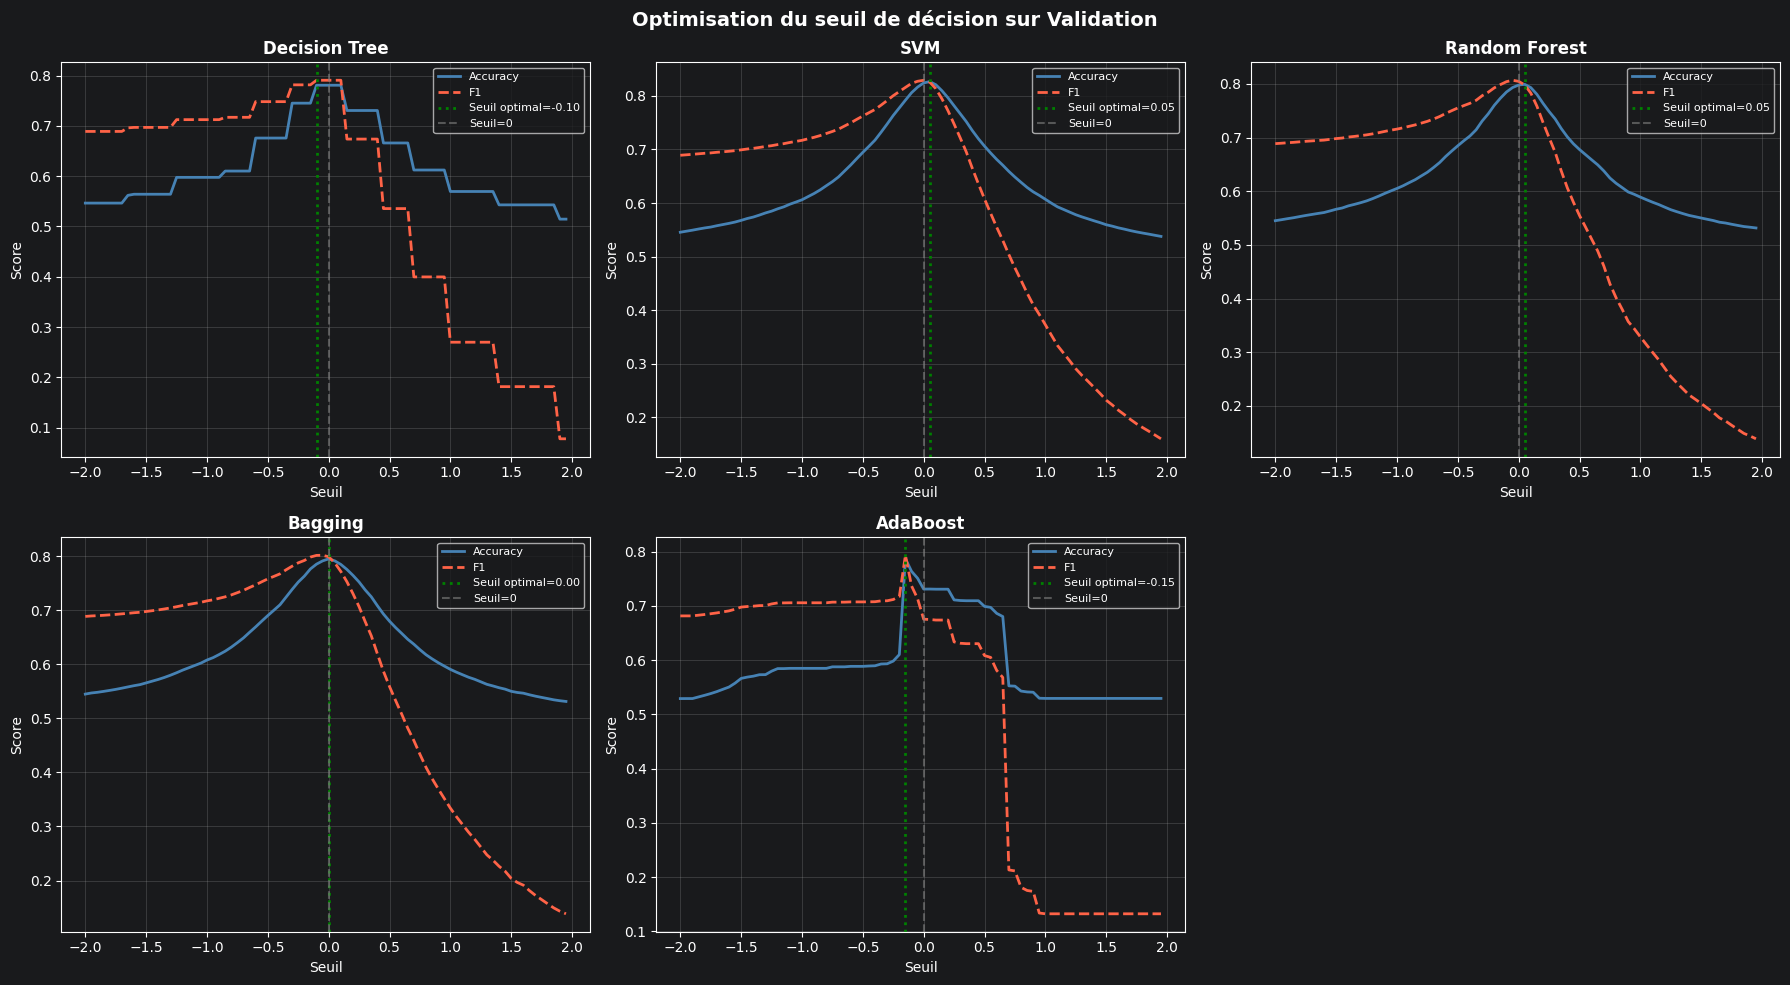

,Modèle,Seuil (s=0),Acc (s=0),Seuil optimal,Acc optimale,Long (%),Short (%)
0,Decision Tree,0.0,0.781,-0.10,0.781,54.2,45.8
1,SVM,0.0,0.824,0.05,0.827,48.9,51.1
2,Random Forest,0.0,0.798,0.05,0.799,49.0,51.0
3,Bagging,0.0,0.795,0.00,0.795,51.4,48.6
4,AdaBoost,0.0,0.731,-0.15,0.787,52.6,47.4


In [6]:
# ── Recherche du seuil optimal sur VALIDATION pour chaque modèle ─────────
seuils = np.arange(-2.0, 2.0, 0.05)
best_thresholds   = {}
threshold_results = []

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

print('Optimisation du seuil sur Validation...')
print('='*75)

for idx, (name, model) in enumerate(reg_models.items()):

    y_pred_val = model.predict(X_val)
    accs_val   = []
    f1s_val    = []

    for seuil in seuils:
        y_lbl = np.where(y_pred_val > seuil, 1, -1)
        accs_val.append(accuracy_score(y_val_clf, y_lbl))
        f1s_val.append(f1_score(y_val_clf, y_lbl, pos_label=1))

    # Meilleur seuil = maximize accuracy sur VAL
    best_idx   = np.argmax(accs_val)
    best_seuil = seuils[best_idx]
    best_acc   = accs_val[best_idx]

    best_thresholds[name] = best_seuil

    # Proportion Long/Short avec ce seuil sur VAL
    y_lbl_val = np.where(y_pred_val > best_seuil, 1, -1)
    pct_long  = np.mean(y_lbl_val == 1)  * 100
    pct_short = np.mean(y_lbl_val == -1) * 100

    threshold_results.append({
        'Modèle'       : name,
        'Seuil (s=0)'  : 0.0,
        'Acc (s=0)'    : round(accs_val[list(seuils).index(min(seuils, key=lambda x: abs(x)))], 3),
        'Seuil optimal': round(best_seuil, 3),
        'Acc optimale' : round(best_acc,   3),
        'Long (%)'     : round(pct_long,   1),
        'Short (%)'    : round(pct_short,  1)
    })

    print(f'{name:<18} Seuil={best_seuil:+.3f} | Acc Val={best_acc:.3f} | Long={pct_long:.0f}% Short={pct_short:.0f}%')

    # Graphe
    ax = axes[idx]
    ax.plot(seuils, accs_val, color='steelblue', linewidth=2, label='Accuracy')
    ax.plot(seuils, f1s_val,  color='tomato',    linewidth=2, label='F1', linestyle='--')
    ax.axvline(best_seuil, color='green', linewidth=2,   linestyle=':',  label=f'Seuil optimal={best_seuil:.2f}')
    ax.axvline(0,          color='gray',  linewidth=1.5, linestyle='--', label='Seuil=0', alpha=0.6)
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Seuil')
    ax.set_ylabel('Score')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.delaxes(axes[5])
plt.suptitle('Optimisation du seuil de décision sur Validation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('='*75)
threshold_df = pd.DataFrame(threshold_results)
threshold_df

## 6. Évaluation Finale sur TEST ⚠️

**Cette cellule ne doit être exécutée qu'une seule fois.**
C'est le verdict final. On applique les meilleurs hyperparamètres ET le meilleur seuil.

In [7]:
# ── Évaluation finale sur TEST avec seuil optimal ────────────────────────
print('ÉVALUATION FINALE SUR TEST (verdict verrouillé)')
print('='*75)
print(f'{"Modèle":<18} {"Seuil":>7} {"R² Test":>9} {"Acc Test":>10} {"Prec":>8} {"Recall":>8} {"F1":>8}')
print('-'*75)

final_results  = []
final_preds    = {}   # pour simulation
final_values   = {}   # valeurs brutes prédites

for name, model in reg_models.items():
    seuil        = best_thresholds[name]
    y_pred_test  = model.predict(X_test)
    y_label_test = np.where(y_pred_test > seuil, 1, -1)

    final_preds[name]  = y_label_test
    final_values[name] = y_pred_test

    r2   = r2_score(y_test_reg, y_pred_test)
    acc  = accuracy_score(y_test_clf,  y_label_test)
    prec = precision_score(y_test_clf, y_label_test, pos_label=1)
    rec  = recall_score(y_test_clf,    y_label_test, pos_label=1)
    f1   = f1_score(y_test_clf,        y_label_test, pos_label=1)

    # Vérification overfitting : Val vs Test
    acc_val = threshold_df.loc[threshold_df['Modèle']==name, 'Acc optimale'].values[0]
    diff    = acc - acc_val
    status  = '✅' if abs(diff) < 0.05 else '⚠️ overfit'

    final_results.append({
        'Modèle'    : name,
        'Seuil'     : round(seuil, 3),
        'R² Test'   : round(r2,   3),
        'Acc Test'  : round(acc,  3),
        'Acc Val'   : round(acc_val, 3),
        'Δ Val-Test': round(diff, 3),
        'Precision' : round(prec, 3),
        'Recall'    : round(rec,  3),
        'F1'        : round(f1,   3),
        'Status'    : status
    })
    print(f'{name:<18} {seuil:>7.3f} {r2:>9.3f} {acc:>10.3f} {prec:>8.3f} {rec:>8.3f} {f1:>8.3f} {status}')

print('='*75)
final_df  = pd.DataFrame(final_results)
best_name = final_df.loc[final_df['Acc Test'].idxmax(), 'Modèle']
best_acc  = final_df['Acc Test'].max()

print(f'\n🏆 Meilleur modèle : {best_name} — Accuracy Test = {best_acc:.3f}')
print(f'   Seuil optimal    : {best_thresholds[best_name]:+.3f}')
print(f'   (seuil=0 donnait : {reg_df.loc[reg_df["Modèle"]==best_name, "Acc Val (s=0)"].values[0]:.3f} sur Val)')
final_df

ÉVALUATION FINALE SUR TEST (verdict verrouillé)
Modèle               Seuil   R² Test   Acc Test     Prec   Recall       F1
---------------------------------------------------------------------------
Decision Tree       -0.100     0.623      0.789    0.781    0.810    0.795 ✅
SVM                  0.050     0.731      0.826    0.832    0.822    0.827 ✅
Random Forest        0.050     0.642      0.799    0.815    0.779    0.797 ✅
Bagging              0.000     0.644      0.792    0.795    0.793    0.794 ✅
AdaBoost            -0.150     0.571      0.789    0.786    0.800    0.793 ✅

🏆 Meilleur modèle : SVM — Accuracy Test = 0.826
   Seuil optimal    : +0.050
   (seuil=0 donnait : 0.824 sur Val)


,Modèle,Seuil,R² Test,Acc Test,Acc Val,Δ Val-Test,Precision,Recall,F1,Status
0,Decision Tree,-0.10,0.623,0.789,0.781,0.008,0.781,0.810,0.795,✅
1,SVM,0.05,0.731,0.826,0.827,-0.001,0.832,0.822,0.827,✅
2,Random Forest,0.05,0.642,0.799,0.799,0.000,0.815,0.779,0.797,✅
3,Bagging,0.00,0.644,0.792,0.795,-0.003,0.795,0.793,0.794,✅
4,AdaBoost,-0.15,0.571,0.789,0.787,0.002,0.786,0.800,0.793,✅


## 7. Matrice de Confusion — Meilleur Modèle

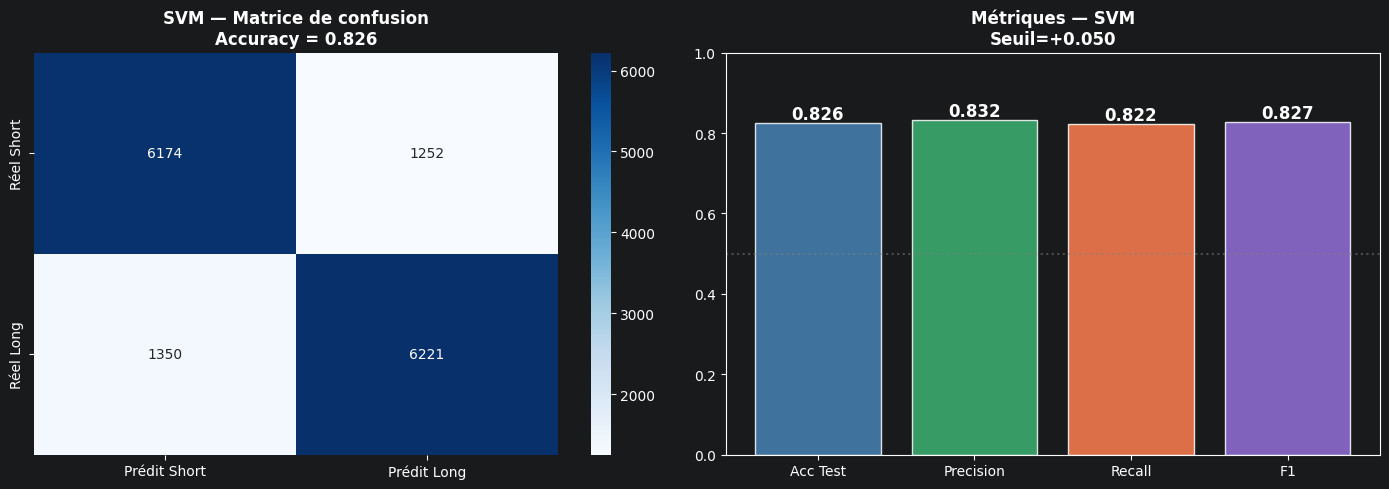


Rapport complet :
              precision    recall  f1-score   support

  Short (-1)       0.82      0.83      0.83      7426
   Long (+1)       0.83      0.82      0.83      7571

    accuracy                           0.83     14997
   macro avg       0.83      0.83      0.83     14997
weighted avg       0.83      0.83      0.83     14997



In [8]:
best_pred = final_preds[best_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion
cm = confusion_matrix(y_test_clf, best_pred, labels=[-1, 1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Prédit Short', 'Prédit Long'],
            yticklabels=['Réel Short', 'Réel Long'])
axes[0].set_title(f'{best_name} — Matrice de confusion\nAccuracy = {best_acc:.3f}', fontweight='bold')

# Métriques détaillées
best_row = final_df[final_df['Modèle'] == best_name].iloc[0]
metrics  = ['Acc Test', 'Precision', 'Recall', 'F1']
vals     = [best_row[m] for m in metrics]
colors   = ['steelblue', 'mediumseagreen', 'coral', 'mediumpurple']
bars     = axes[1].bar(metrics, vals, color=colors, alpha=0.85, edgecolor='white')
axes[1].set_ylim(0, 1)
axes[1].axhline(0.5, color='gray', linestyle=':', alpha=0.5)
axes[1].set_title(f'Métriques — {best_name}\nSeuil={best_thresholds[best_name]:+.3f}', fontweight='bold')
for bar in bars:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{bar.get_height():.3f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nRapport complet :')
print(classification_report(y_test_clf, best_pred, target_names=['Short (-1)', 'Long (+1)']))

## 8. Simulation de Trading Réaliste

On intègre maintenant les **coûts réels du broker** :
- Spread : 0.60 USD par trade
- SWAP overnight : -0.01703% (long) / +0.00314% (short)
- Filtre session US : 14h30–21h00 UTC uniquement

In [9]:
# ── Données test pour simulation ──────────────────────────────────────────
test_sim = test.copy()
test_sim['ml_signal']  = final_preds[best_name]

# ── Filtre session US (14h30–21h00 UTC) ──────────────────────────────────
test_sim['heure']      = test_sim.index.hour
test_sim['session_us'] = (
    (test_sim['heure'] >= 14) &
    (test_sim['heure'] <= 21)
)

# Signal filtré : 0 hors session (pas de position)
test_sim['ml_signal_filtered'] = np.where(
    test_sim['session_us'],
    test_sim['ml_signal'],
    0
)

# ── Double MA Strategy (baseline) ────────────────────────────────────────
test_sim['ma10']     = test_sim['close'].rolling(10).mean()
test_sim['dma_signal'] = np.where(
    test_sim['ma5'] > test_sim['ma10'],  1,
    np.where(test_sim['ma5'] < test_sim['ma10'], -1, 0)
)
test_sim.dropna(inplace=True)

# ── Rendements log ────────────────────────────────────────────────────────
test_sim['log_ret'] = np.log(test_sim['close'] / test_sim['close'].shift(1))
test_sim.dropna(inplace=True)

# ── Changements de position (= un trade = coût spread) ───────────────────
test_sim['change_ml']      = (test_sim['ml_signal_filtered'] != test_sim['ml_signal_filtered'].shift(1)).astype(int)
test_sim['change_dma']     = (test_sim['dma_signal']         != test_sim['dma_signal'].shift(1)).astype(int)

nb_trades_ml  = test_sim['change_ml'].sum()
nb_trades_dma = test_sim['change_dma'].sum()
print(f'Nombre de trades ML  : {nb_trades_ml:,}')
print(f'Nombre de trades DMA : {nb_trades_dma:,}')
print(f'Coût spread ML       : {nb_trades_ml * SPREAD_USD:,.2f} USD')
print(f'Coût spread DMA      : {nb_trades_dma * SPREAD_USD:,.2f} USD')

# ── Rendements nets (après spread) ───────────────────────────────────────
cout_spread_par_trade = SPREAD_USD / CAPITAL_INIT

test_sim['ret_ml_brut']  = test_sim['ml_signal_filtered'].shift(1) * test_sim['log_ret']
test_sim['ret_ml_net']   = test_sim['ret_ml_brut']  - (test_sim['change_ml']  * cout_spread_par_trade)
test_sim['ret_dma_brut'] = test_sim['dma_signal'].shift(1) * test_sim['log_ret']
test_sim['ret_dma_net']  = test_sim['ret_dma_brut'] - (test_sim['change_dma'] * cout_spread_par_trade)
test_sim['ret_bh']       = test_sim['log_ret']
test_sim.dropna(inplace=True)

# ── SWAP overnight ────────────────────────────────────────────────────────
swap_cost_ml = 0
for idx_row, row in test_sim[test_sim.index.hour == 23].iterrows():
    mult = 3 if idx_row.dayofweek == 4 else 1  # triple swap vendredi
    if row['ml_signal_filtered'] == 1:
        swap_cost_ml += CAPITAL_INIT * abs(SWAP_LONG_PCT)  * mult
    elif row['ml_signal_filtered'] == -1:
        swap_cost_ml += CAPITAL_INIT * abs(SWAP_SHORT_PCT) * mult

print(f'\nCoût SWAP overnight ML : {swap_cost_ml:,.2f} USD')
print(f'Coût TOTAL ML          : {nb_trades_ml * SPREAD_USD + swap_cost_ml:,.2f} USD')

# ── Equity curves ─────────────────────────────────────────────────────────
test_sim['equity_ml_net']  = CAPITAL_INIT * np.exp(test_sim['ret_ml_net'].cumsum())
test_sim['equity_dma_net'] = CAPITAL_INIT * np.exp(test_sim['ret_dma_net'].cumsum())
test_sim['equity_bh']      = CAPITAL_INIT * np.exp(test_sim['ret_bh'].cumsum())

# Ajustement SWAP sur equity ML
test_sim['equity_ml_net'] -= swap_cost_ml / len(test_sim)

print('\n✅ Simulation prête')

Nombre de trades ML  : 1,126
Nombre de trades DMA : 1,676
Coût spread ML       : 675.60 USD
Coût spread DMA      : 1,005.60 USD

Coût SWAP overnight ML : 0.00 USD
Coût TOTAL ML          : 675.60 USD

✅ Simulation prête


## 9. Résultats de Trading

  RÉSULTATS TRADING (coûts broker intégrés)
                         ML Strategy (SVM)  Double MA Strategy  Buy & Hold
Capital final ($)                90415.000          100060.000  103613.000
Rendement annualisé (%)            -12.380               0.080       4.770
Max Drawdown (%)                   -12.930             -11.760      -9.810
Sharpe Ratio                        -1.923               0.008       0.465


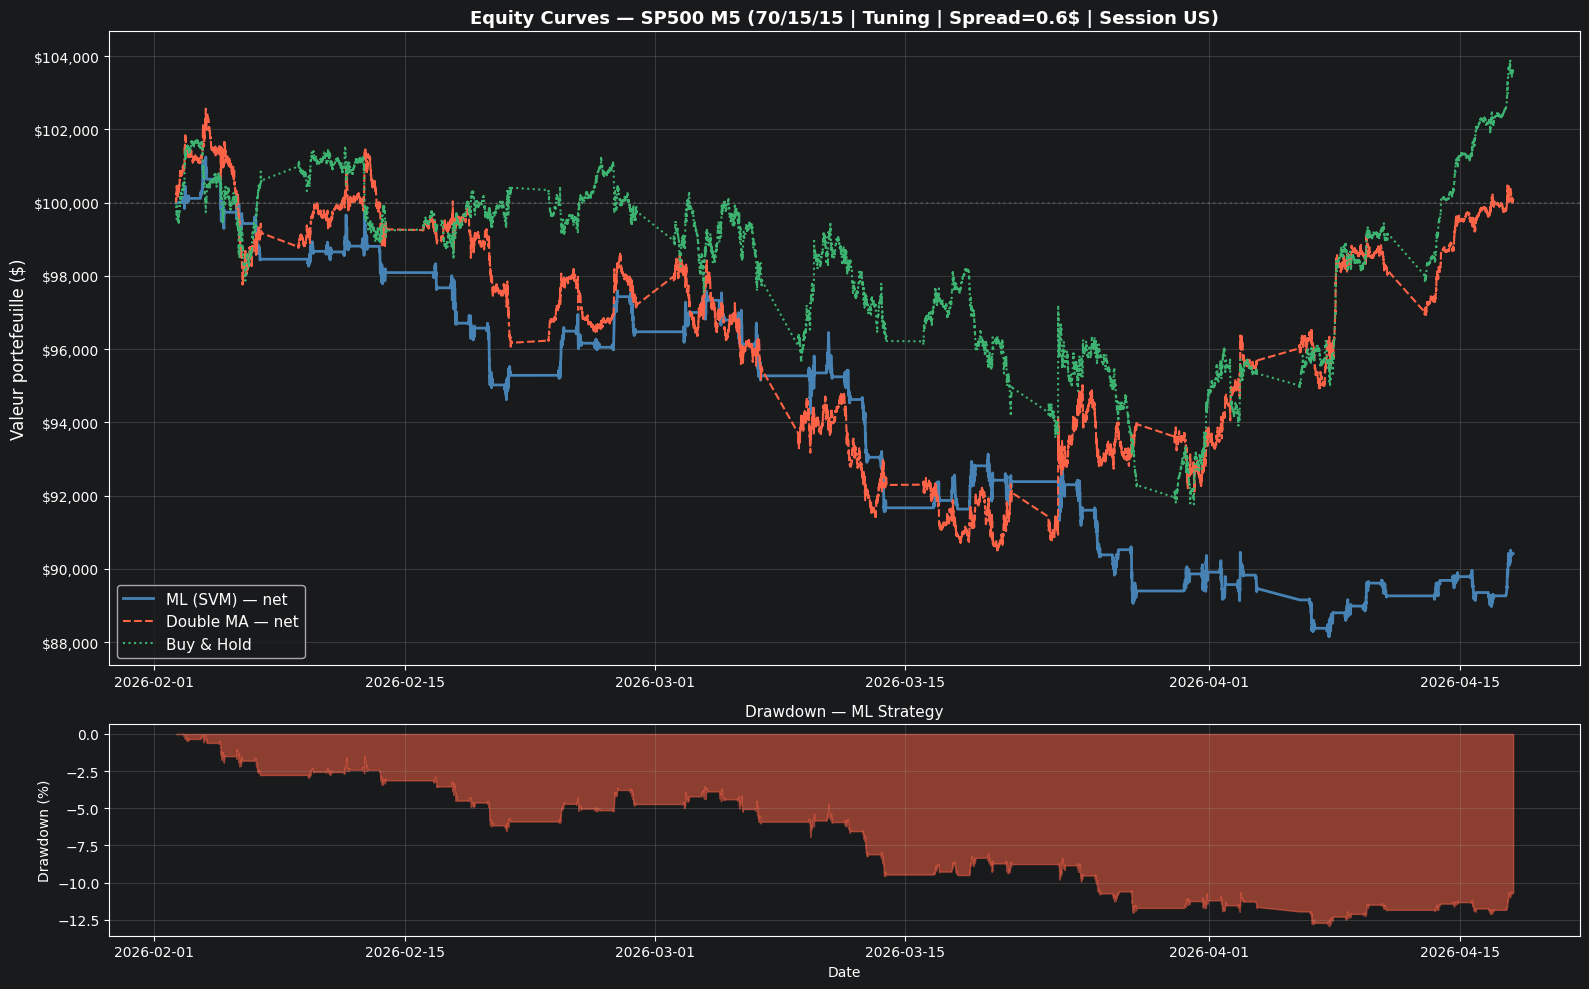

In [10]:
def compute_metrics(ret_series, equity_series):
    total_ret   = np.exp(ret_series.sum()) - 1
    n           = len(ret_series)
    annualized  = (1 + total_ret) ** (BOUGIES_PAR_AN / n) - 1
    peak        = equity_series.cummax()
    dd          = (equity_series - peak) / peak
    max_dd      = dd.min()
    sharpe      = ret_series.mean() / ret_series.std() * np.sqrt(BOUGIES_PAR_AN) if ret_series.std() > 0 else 0
    return {
        'Capital final ($)' : round(equity_series.iloc[-1], 0),
        'Rendement annualisé (%)': round(annualized * 100, 2),
        'Max Drawdown (%)'  : round(max_dd * 100, 2),
        'Sharpe Ratio'      : round(sharpe, 3)
    }

m_ml  = compute_metrics(test_sim['ret_ml_net'],  test_sim['equity_ml_net'])
m_dma = compute_metrics(test_sim['ret_dma_net'], test_sim['equity_dma_net'])
m_bh  = compute_metrics(test_sim['ret_bh'],      test_sim['equity_bh'])

results_table = pd.DataFrame({
    f'ML Strategy ({best_name})': m_ml,
    'Double MA Strategy'        : m_dma,
    'Buy & Hold'                : m_bh
})

print('='*65)
print('  RÉSULTATS TRADING (coûts broker intégrés)')
print('='*65)
print(results_table.to_string())
print('='*65)

# ── Graphique equity curves + drawdown ────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [3, 1]})

axes[0].plot(test_sim.index, test_sim['equity_ml_net'],  label=f'ML ({best_name}) — net',  color='steelblue',     linewidth=2)
axes[0].plot(test_sim.index, test_sim['equity_dma_net'], label='Double MA — net',           color='tomato',        linewidth=1.5, linestyle='--')
axes[0].plot(test_sim.index, test_sim['equity_bh'],      label='Buy & Hold',                color='mediumseagreen',linewidth=1.5, linestyle=':')
axes[0].axhline(CAPITAL_INIT, color='gray', linestyle=':', alpha=0.4)
axes[0].set_title(f'Equity Curves — SP500 M5 (70/15/15 | Tuning | Spread={SPREAD_USD}$ | Session US)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Valeur portefeuille ($)', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
axes[0].grid(True, alpha=0.3)

# Drawdown ML
peak   = test_sim['equity_ml_net'].cummax()
dd_ml  = (test_sim['equity_ml_net'] - peak) / peak * 100
axes[1].fill_between(test_sim.index, dd_ml, 0, color='tomato', alpha=0.5)
axes[1].set_title('Drawdown — ML Strategy', fontsize=11)
axes[1].set_ylabel('Drawdown (%)')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Résumé Final

In [11]:
print('='*65)
print('  RÉSUMÉ FINAL — Wang & Yan SP500 M5 (Version Pro)')
print('='*65)
print(f'  Split              : 70% Train | 15% Val | 15% Test')
print(f'  Tuning             : RandomizedSearch {N_ITER_SEARCH} iter × {N_CV_FOLDS} folds TS')
print(f'  Meilleur modèle    : {best_name}')
print(f'  Seuil optimal      : {best_thresholds[best_name]:+.3f} (au lieu de 0)')
print(f'  Accuracy Test      : {best_acc:.3f}')
print(f'  Capital final ML   : ${m_ml["Capital final ($)"]:,.0f}')
print(f'  Rendement ML       : {m_ml["Rendement annualisé (%)"]:.2f}% annualisé')
print(f'  Sharpe ML          : {m_ml["Sharpe Ratio"]:.3f}')
print(f'  Max Drawdown ML    : {m_ml["Max Drawdown (%)"]:.2f}%')
print('='*65)
print('\nComparaison Val vs Test (contrôle overfitting) :')
for _, row in final_df.iterrows():
    print(f'  {row["Modèle"]:<18} Val={row["Acc Val"]:.3f} | Test={row["Acc Test"]:.3f} | Δ={row["Δ Val-Test"]:+.3f} {row["Status"]}')
print('='*65)

  RÉSUMÉ FINAL — Wang & Yan SP500 M5 (Version Pro)
  Split              : 70% Train | 15% Val | 15% Test
  Tuning             : RandomizedSearch 30 iter × 5 folds TS
  Meilleur modèle    : SVM
  Seuil optimal      : +0.050 (au lieu de 0)
  Accuracy Test      : 0.826
  Capital final ML   : $90,415
  Rendement ML       : -12.38% annualisé
  Sharpe ML          : -1.923
  Max Drawdown ML    : -12.93%

Comparaison Val vs Test (contrôle overfitting) :
  Decision Tree      Val=0.781 | Test=0.789 | Δ=+0.008 ✅
  SVM                Val=0.827 | Test=0.826 | Δ=-0.001 ✅
  Random Forest      Val=0.799 | Test=0.799 | Δ=+0.000 ✅
  Bagging            Val=0.795 | Test=0.792 | Δ=-0.003 ✅
  AdaBoost           Val=0.787 | Test=0.789 | Δ=+0.002 ✅
